In [137]:
import h5py
import psana
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import  rotate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,minimize
from matplotlib.backends.backend_pdf import PdfPages
import multiprocessing
import os
from functools import partial
import time
import sys
import argparse
from datetime import datetime
import tempfile
import XSpect.XSpect_Analysis
import XSpect.XSpect_Controller
import XSpect.XSpect_Visualization
import XSpect.XSpect_Diagnostics as dt
import XSpect.XSpect_PostProcessing

Run 96 imported


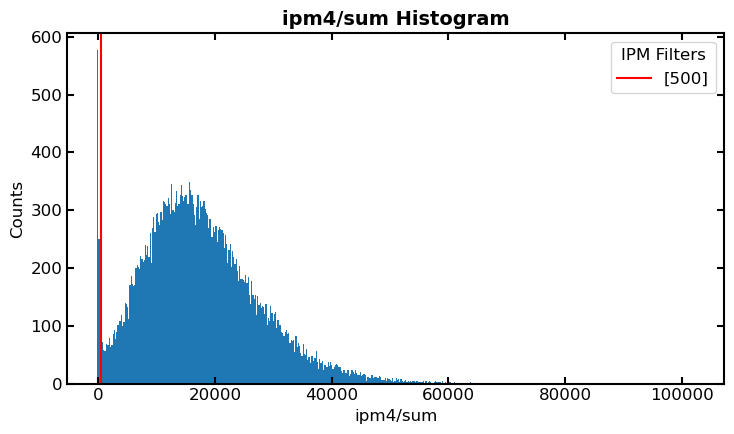

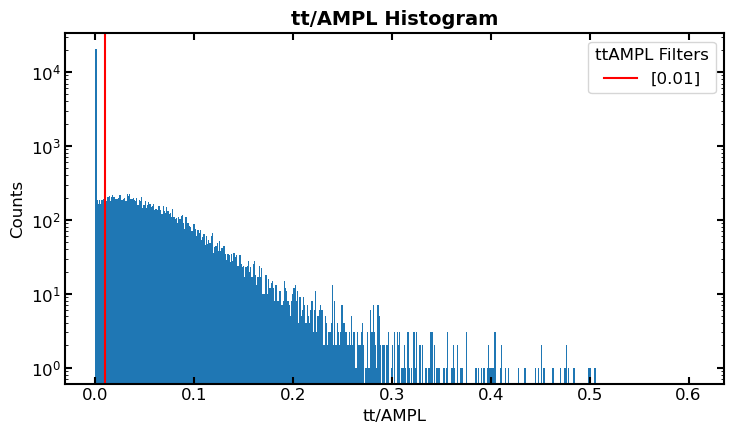

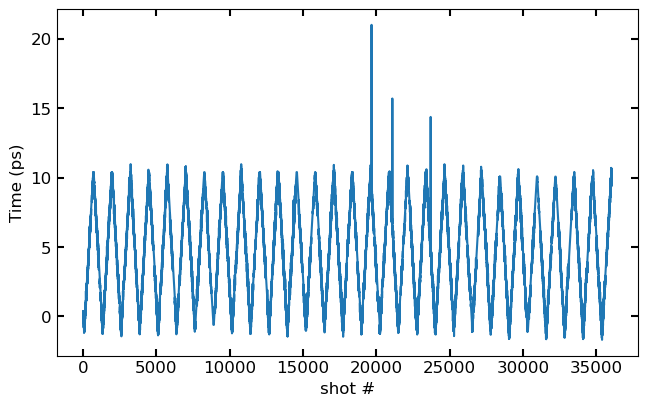

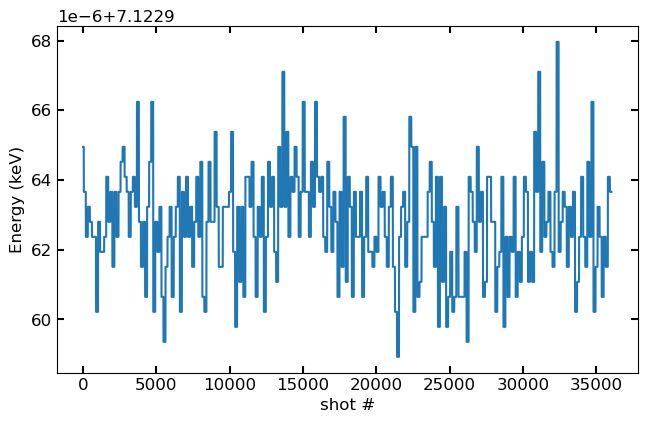

In [138]:
run = 96
exp = 'xcs101237825'
keys=['epicsUser/dccm_E', 'epicsUser/dccm_E_setpoint', 'tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl']

# pdf = PdfPages("output.pdf")

d = dt.diagnostics(run, exp, keys, names)

ipm_thres = [500]

d.ipm_histogram(ipm_thres)

# figx = plt.gcf()
# pdf.savefig(figx)

tt_thres = [0.01]

d.ttAMPL_histogram(tt_thres)

# d.droplet_histogram()

nshots = 1000

# adu_thres = [3.5]
# d.adu_histogram(nshots, adu_thres)

# ka_roi_d = [270, 300]
# kb_roi_d = [180, 220]

# d.detector_sum_ROI(ka_roi_d, kb_roi_d)

# ka_roi = [100, 120]
# kb_roi = [15, 55]

# d.xes_ROI(nshots, ka_limits = ka_roi, kb_limits = kb_roi, angle = 0)

# d.xes_ROI(nshots, ka_limits = ka_roi, kb_limits = kb_roi, angle = 1.4)

delay = d.h5[d.datadict['time_tool_correction']][:] + d.h5[d.datadict['lxt_ttc']][:]*1e12 + d.h5[d.datadict['encoder']][:]

plt.plot(delay)
plt.ylabel('Time (ps)')
plt.xlabel('shot #')
plt.show()

plt.plot(d.h5['epicsUser']['dccm_E'][:])
plt.xlabel('shot #')
plt.ylabel('Energy (keV)')
plt.show()

# pdf.close()

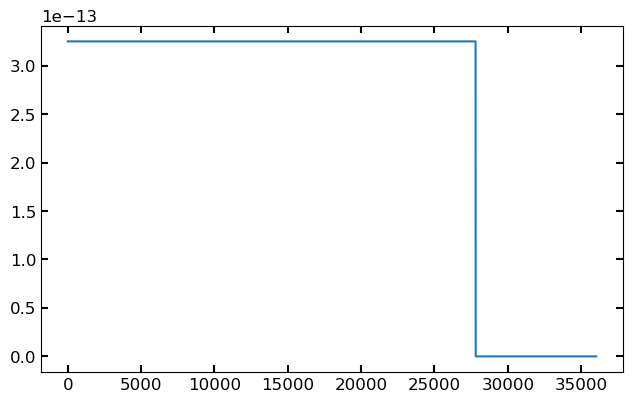

In [26]:
plt.plot(d.h5[d.datadict['lxt_ttc']][:])

### XANES 1D Time

In [144]:
start = time.time()

xspect_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(hutch='xcs',experiment_id=exp,lcls_run=exp[-2:])
xes1=XSpect.XSpect_Controller.XASBatchAnalysis_1D_time()
keys=['epicsUser/dccm_E', 'epicsUser/dccm_E_setpoint', 'tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL', 'epix_2/ROI_sum'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl', 'epix']

#Here we define the epix detector keys separately as they are imported separately to avoid OOM
# xes1.key_epix=['epix_2/ROI_sum']
# xes1.friendly_name_epix=['epix']

##

xes1.mintime = -2 # ps80
xes1.maxtime = 20 # ps
xes1.time_step = 0.5 # ps
xes1.time_bins  = np.arange(xes1.mintime, xes1.maxtime+xes1.time_step, xes1.time_step)

xes1.set_key_aliases(keys,names)

xes1.transpose=False
xes1.add_filter('xray','ipm',500)
xes1.add_filter('simultaneous','ipm',500)
xes1.scattering = True

xes1.run_parser(['161']) # 1 ns

In [145]:
start=time.time()

xes1.primary_analysis_loop(xspect_experiment, verbose = True)

end=time.time()
print('Analysis completed: %.02f s' % (end - start))

Obtained shot properties
HDF5 import of keys completed. Time: 0.06 seconds
------Timing data values are either very small or zero. Confirm the units and keys are correct-----
-----Mean abs value of: lxt_key: 0.000000, fast_delay: 9.222572, tt_correction: 0.041607 -----
Generated timing bins from -2.000000 to 20.000000 in 45 steps.
Mask: xray has been filtered on ipm by minimum threshold: 500.000
Shots removed: 2509
Mask: simultaneous has been filtered on ipm by minimum threshold: 500.000
Shots removed: 11865
Mask: xray has been filtered on delays by minimum threshold: -2.250 and maximum threshold: 20.250
Shots removed: 29
Mask: simultaneous has been filtered on delays by minimum threshold: -2.250 and maximum threshold: 20.250
Shots removed: 59
Shots (27057) combined for detector epix on filters: simultaneous and laser into epix_simultaneous_laser
Shots (7893) separated for detector epix on filters: xray and laser into epix_xray_not_laser
Shots (27057) combined for detector ipm on filte

In [146]:
run_count = 0
for ii, run in enumerate(xes1.analyzed_runs):
    print(ii)
    # print(run.ccm_bins.shape)
    # print(run.epix_simultaneous_laser_energy_binned.shape)
    # print(run.epix_xray_not_laser_energy_binned.shape)
    run_count+=1

0


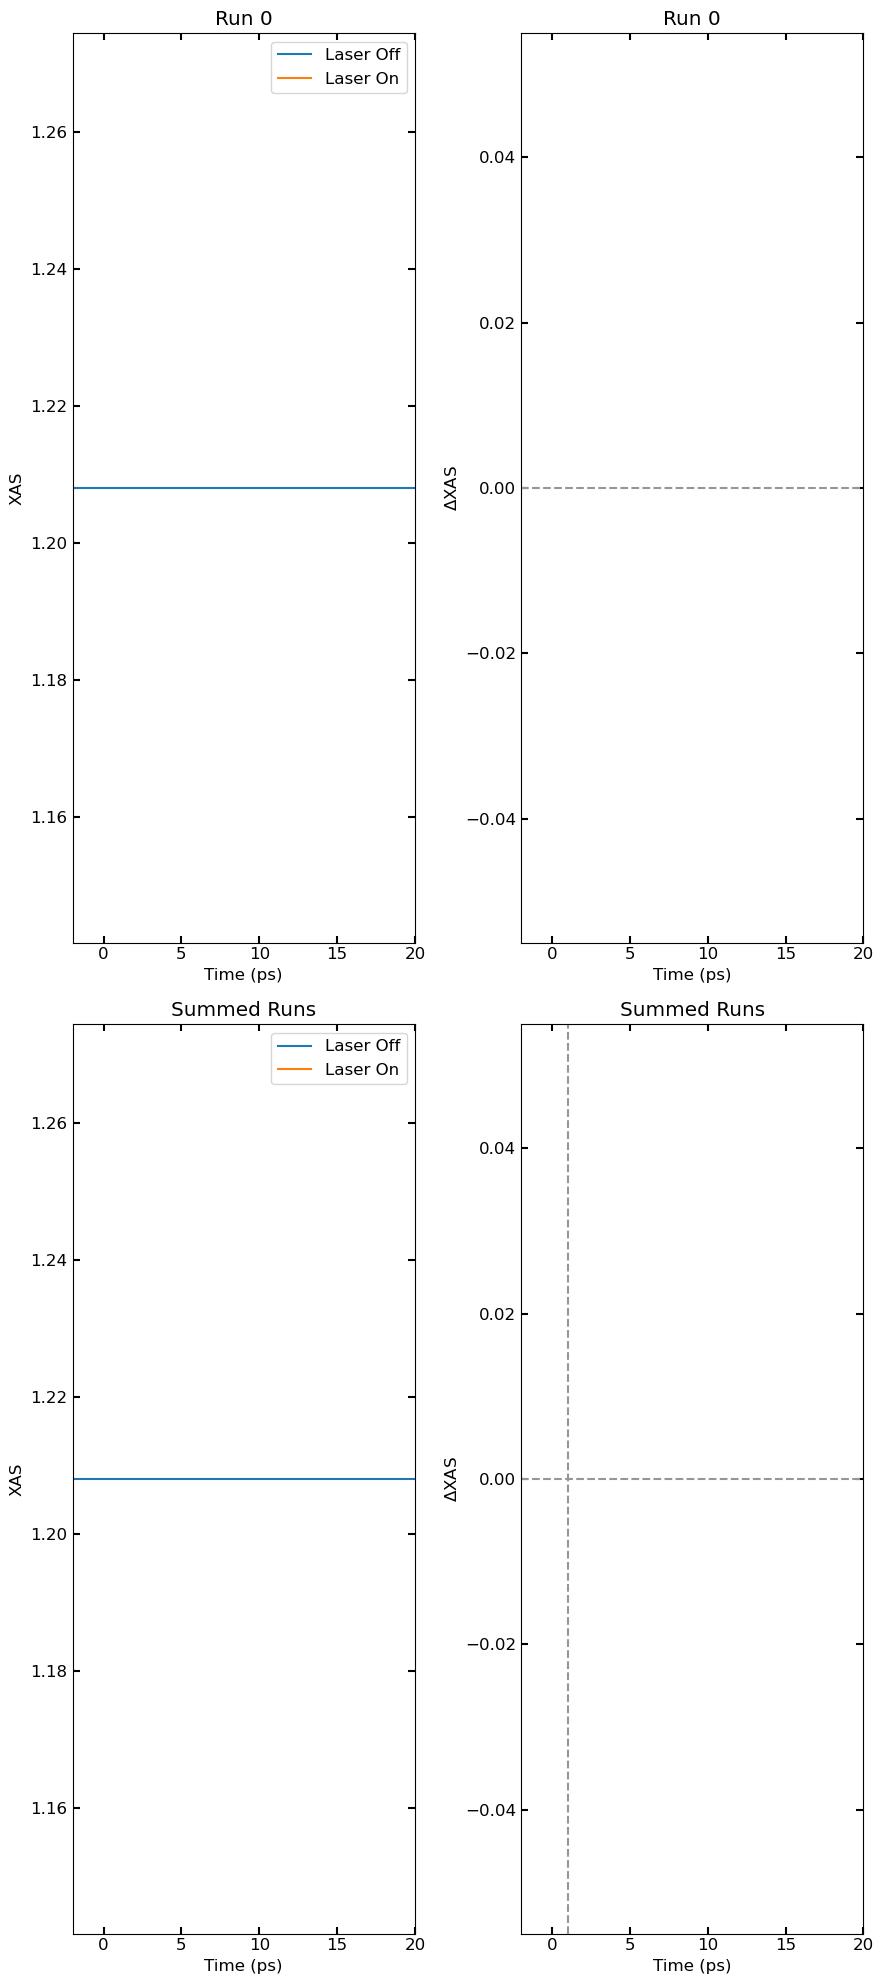

In [148]:
fig, ax = plt.subplots(figsize = (9,20), nrows = run_count+1, ncols = 2)

xas_loff_sum = np.zeros_like(xes1.analyzed_runs[0].epix_xray_not_laser_time_binned)
xas_lon_sum = np.zeros_like(xes1.analyzed_runs[0].epix_simultaneous_laser_time_binned)

for ii, run in enumerate(xes1.analyzed_runs):
    xas_loff_norm = run.epix_xray_not_laser_time_binned/run.ipm_xray_not_laser_time_binned
    xas_loff_norm_mean = np.ones_like(xas_loff_norm)*np.nanmean(xas_loff_norm)
    xas_lon_norm = run.epix_simultaneous_laser_time_binned/run.ipm_simultaneous_laser_time_binned
    xas_diff_norm = xas_lon_norm - xas_loff_norm_mean

    plt_indx0 = (ii,0)
    plt_indx1 = (ii,1)

    ax[plt_indx0].plot(run.time_bins, xas_loff_norm_mean, label = 'Laser Off')
    ax[plt_indx0].plot(run.time_bins, xas_lon_norm, label = 'Laser On')
    ax[plt_indx0].set_xlim([np.min(run.time_bins), np.max(run.time_bins)])
    ax[plt_indx0].set_xlabel('Time (ps)')
    ax[plt_indx0].set_ylabel('XAS')
    ax[plt_indx0].legend()
    ax[plt_indx0].set_title('Run %i' % ii)

    ax[plt_indx1].plot(run.time_bins, xas_diff_norm, label = 'Difference')
    ax[plt_indx1].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
    ax[plt_indx1].set_xlim([np.min(run.time_bins), np.max(run.time_bins)])
    ax[plt_indx1].set_xlabel('Time (ps)')
    ax[plt_indx1].set_ylabel(r'$\Delta$XAS')
    ax[plt_indx1].set_title('Run %i' % ii)
    
    xas_loff_sum += xas_loff_norm
    xas_lon_sum += xas_lon_norm

xas_loff_sumtotal = np.ones_like(xas_loff_norm)*np.nanmean(xas_loff_sum)
xas_diff_sum = xas_lon_sum - xas_loff_sum

plt_indx0_sum = (ii+1,0)
plt_indx1_sum = (ii+1,1)

ax[plt_indx0_sum].plot(run.time_bins, xas_loff_sumtotal, label = 'Laser Off')
ax[plt_indx0_sum].plot(run.time_bins, xas_lon_sum, label = 'Laser On')
ax[plt_indx0_sum].set_xlim([np.min(run.time_bins), np.max(run.time_bins)])
ax[plt_indx0_sum].set_xlabel('Time (ps)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Summed Runs')

ax[plt_indx1_sum].plot(run.time_bins, xas_diff_sum, label = 'Difference')
ax[plt_indx1_sum].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlim([np.min(run.time_bins), np.max(run.time_bins)])
ax[plt_indx1_sum].axvline(1, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlabel('Time (ps)')
ax[plt_indx1_sum].set_ylabel(r'$\Delta$XAS')
ax[plt_indx1_sum].set_title('Summed Runs')

plt.tight_layout()

Obtained shot properties
HDF5 import of keys completed. Time: 0.00 seconds
------Timing data values are either very small or zero. Confirm the units and keys are correct-----
-----Mean abs value of: lxt_key: 0.000000, fast_delay: 4.684587, tt_correction: 0.181464 -----
Generated timing bins from -1.000000 to 10.000000 in 45 steps.
Mask: xray has been filtered on ipm by minimum threshold: 500.000
Shots removed: 667
Mask: simultaneous has been filtered on ipm by minimum threshold: 500.000
Shots removed: 472
Mask: xray has been filtered on delays by minimum threshold: -1.125 and maximum threshold: 10.125
Shots removed: 1110
Mask: simultaneous has been filtered on delays by minimum threshold: -1.125 and maximum threshold: 10.125
Shots removed: 751
Shots (24325) combined for detector epix on filters: simultaneous and laser into epix_simultaneous_laser
Shots (9666) separated for detector epix on filters: xray and laser into epix_xray_not_laser
Shots (24325) combined for detector ipm on filte

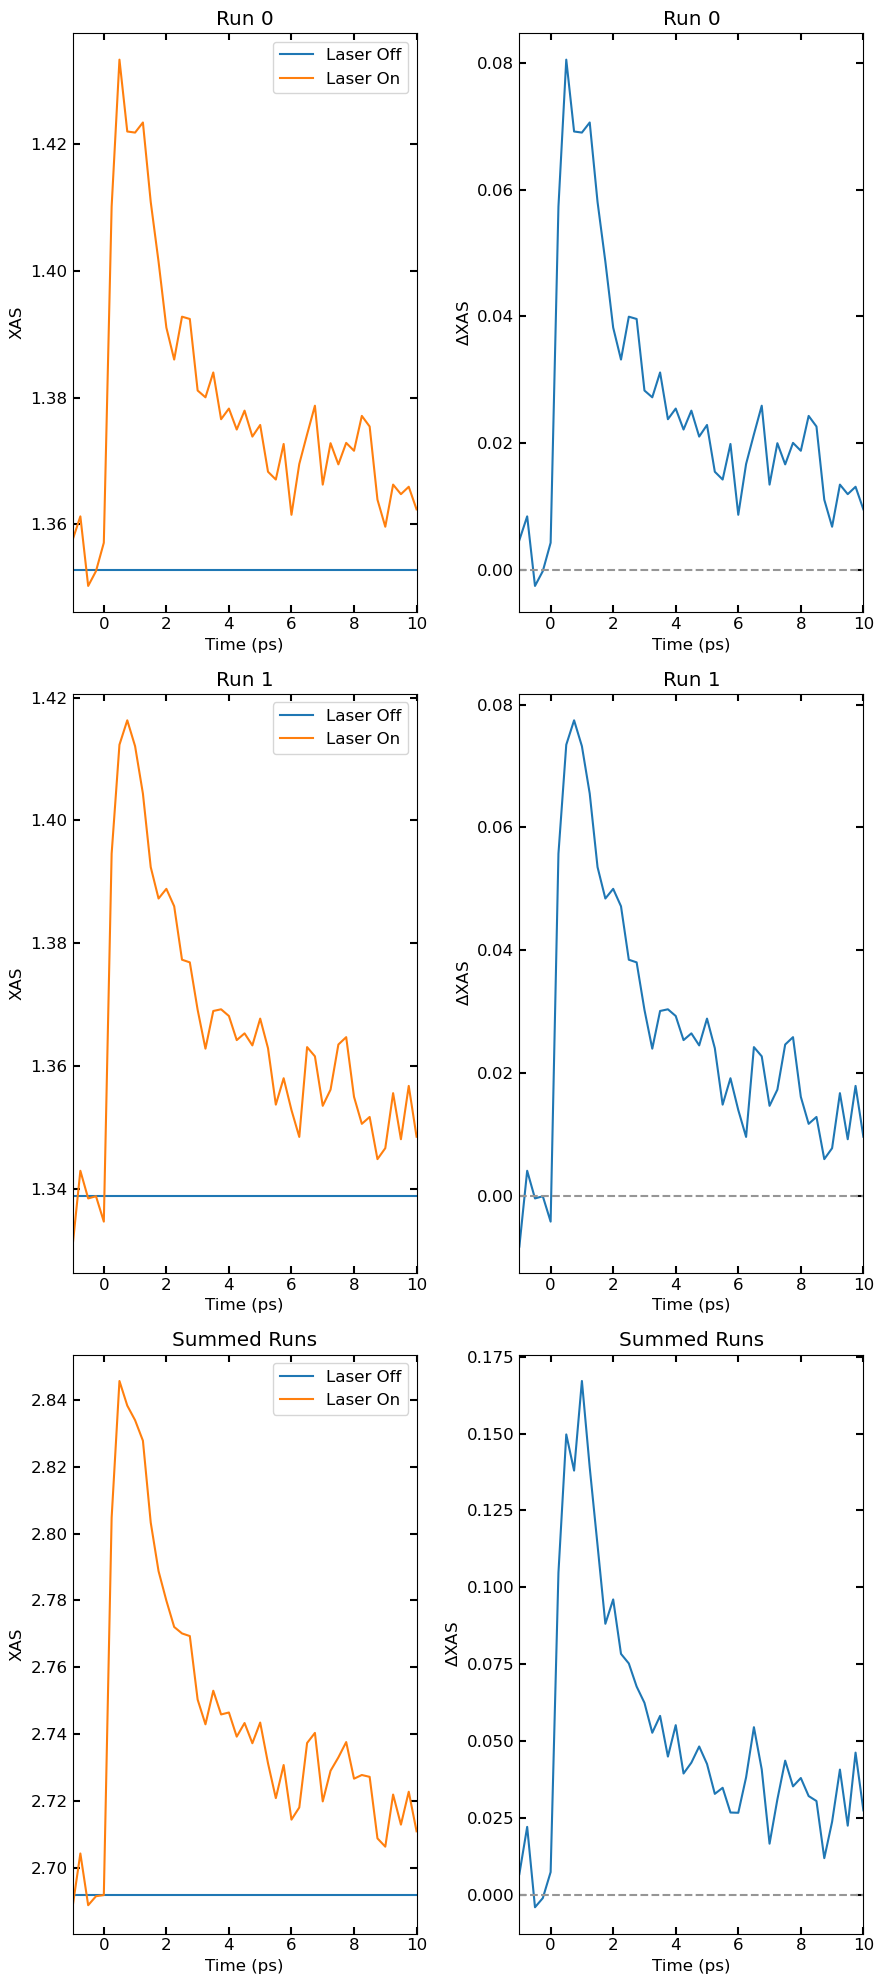

In [133]:
start = time.time()

xspect_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(hutch='xcs',experiment_id=exp,lcls_run=exp[-2:])
xes1=XSpect.XSpect_Controller.XASBatchAnalysis_1D_time()
keys=['epicsUser/dccm_E', 'epicsUser/dccm_E_setpoint', 'tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL', 'epix_2/ROI_sum'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl', 'epix']

#Here we define the epix detector keys separately as they are imported separately to avoid OOM
# xes1.key_epix=['epix_2/ROI_sum']
# xes1.friendly_name_epix=['epix']

##

xes1.mintime = -1 # ps
xes1.maxtime = 10 # ps
xes1.time_step = 0.25 # ps
xes1.time_bins  = np.arange(xes1.mintime, xes1.maxtime+xes1.time_step, xes1.time_step)

xes1.set_key_aliases(keys,names)

xes1.transpose=False
xes1.add_filter('xray','ipm',500)
xes1.add_filter('simultaneous','ipm',500)
xes1.scattering = True

xes1.run_parser(['96 97 ']) # 1 ns

start=time.time()

xes1.primary_analysis_loop(xspect_experiment, verbose = True)

end=time.time()
print('Analysis completed: %.02f s' % (end - start))

run_count = 0
for ii, run in enumerate(xes1.analyzed_runs):
    print(ii)
    # print(run.ccm_bins.shape)
    # print(run.epix_simultaneous_laser_energy_binned.shape)
    # print(run.epix_xray_not_laser_energy_binned.shape)
    run_count+=1

fig, ax = plt.subplots(figsize = (9,20), nrows = run_count+1, ncols = 2)

xas_loff_sum = np.zeros_like(xes1.analyzed_runs[0].epix_xray_not_laser_time_binned)
xas_lon_sum = np.zeros_like(xes1.analyzed_runs[0].epix_simultaneous_laser_time_binned)

for ii, run in enumerate(xes1.analyzed_runs):
    xas_loff_norm = run.epix_xray_not_laser_time_binned/run.ipm_xray_not_laser_time_binned
    xas_loff_norm_mean = np.ones_like(xas_loff_norm)*np.nanmean(xas_loff_norm)
    xas_lon_norm = run.epix_simultaneous_laser_time_binned/run.ipm_simultaneous_laser_time_binned
    xas_diff_norm = xas_lon_norm - xas_loff_norm_mean

    plt_indx0 = (ii,0)
    plt_indx1 = (ii,1)

    ax[plt_indx0].plot(run.time_bins, xas_loff_norm_mean, label = 'Laser Off')
    ax[plt_indx0].plot(run.time_bins, xas_lon_norm, label = 'Laser On')
    ax[plt_indx0].set_xlim([np.min(run.time_bins), np.max(run.time_bins)])
    ax[plt_indx0].set_xlabel('Time (ps)')
    ax[plt_indx0].set_ylabel('XAS')
    ax[plt_indx0].legend()
    ax[plt_indx0].set_title('Run %i' % ii)

    ax[plt_indx1].plot(run.time_bins, xas_diff_norm, label = 'Difference')
    ax[plt_indx1].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
    ax[plt_indx1].set_xlim([np.min(run.time_bins), np.max(run.time_bins)])
    ax[plt_indx1].set_xlabel('Time (ps)')
    ax[plt_indx1].set_ylabel(r'$\Delta$XAS')
    ax[plt_indx1].set_title('Run %i' % ii)
    
    xas_loff_sum += xas_loff_norm
    xas_lon_sum += xas_lon_norm

xas_loff_sumtotal = np.ones_like(xas_loff_norm)*np.nanmean(xas_loff_sum)
xas_diff_sum = xas_lon_sum - xas_loff_sum

plt_indx0_sum = (ii+1,0)
plt_indx1_sum = (ii+1,1)

ax[plt_indx0_sum].plot(run.time_bins, xas_loff_sumtotal, label = 'Laser Off')
ax[plt_indx0_sum].plot(run.time_bins, xas_lon_sum, label = 'Laser On')
ax[plt_indx0_sum].set_xlim([np.min(run.time_bins), np.max(run.time_bins)])
ax[plt_indx0_sum].set_xlabel('Time (ps)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Summed Runs')

ax[plt_indx1_sum].plot(run.time_bins, xas_diff_sum, label = 'Difference')
ax[plt_indx1_sum].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlim([np.min(run.time_bins), np.max(run.time_bins)])
ax[plt_indx1_sum].set_xlabel('Time (ps)')
ax[plt_indx1_sum].set_ylabel(r'$\Delta$XAS')
ax[plt_indx1_sum].set_title('Summed Runs')

plt.tight_layout()

In [105]:
###### Utkarhs

In [143]:
output_array = np.column_stack((
    run.time_bins,
    xas_loff_sumtotal,
    xas_lon_sum,
    xas_diff_sum
))

# Save to txt
np.savetxt(
    'summed_run_7126_n2q_1.txt',
    output_array,
    header='Time_ps\tLaser_Off\tLaser_On\tDifference',
    fmt='%.6e',
    delimiter='\t'
)